In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
df = pd.read_csv('istanbul_apartment_prices_2026.csv')
df.head()

,listing_id,price,price_per_sqm,district,neighborhood,rooms,halls,total_rooms,gross_sqm,net_sqm,...,usage_status,is_in_complex,complex_name,orientation,maintenance_fee,credit_eligible,deed_status,exchange,last_updated,scraped_at
0,54895-1121,15900000,165625.00,Adalar,Maden,3,1,4,138.0,96.0,...,Vacant,0,NaN,"North, South, East, West",2500.0,Not Eligible,Land Title,No,2026-03-11,2026-03-14T20:38:29
1,54895-1103,40000000,266666.67,Adalar,Nizam,4,1,5,199.0,150.0,...,Vacant,1,NaN,"North, South, East, West",10000.0,Eligible,Construction Easement,No,2026-03-05,2026-03-14T20:38:36
2,54895-1148,17850000,220370.37,Adalar,Nizam,2,1,3,107.0,81.0,...,Vacant,0,NaN,"North, East, West",1000.0,Eligible,Condominium Title,No,2026-03-05,2026-03-14T20:38:47
3,12854-258,16000000,81632.65,Adalar,Heybeliada,3,1,4,200.0,196.0,...,Owner-occupied,0,NaN,"North, West",NaN,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:38:56
4,121334-99,14000000,96551.72,Adalar,Nizam,4,1,5,160.0,145.0,...,Vacant,0,NaN,NaN,400.0,Eligible,Condominium Title,No,2026-03-14,2026-03-14T20:39:04


In [4]:
df.columns

Index(['listing_id', 'price', 'price_per_sqm', 'district', 'neighborhood',
       'rooms', 'halls', 'total_rooms', 'gross_sqm', 'net_sqm', 'floor',
       'floor_category', 'total_floors', 'building_age', 'building_type',
       'building_condition', 'heating_type', 'fuel_type', 'bathroom_count',
       'furnished', 'usage_status', 'is_in_complex', 'complex_name',
       'orientation', 'maintenance_fee', 'credit_eligible', 'deed_status',
       'exchange', 'last_updated', 'scraped_at'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24767 entries, 0 to 24766
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   listing_id          24767 non-null  object 
 1   price               24767 non-null  int64  
 2   price_per_sqm       24767 non-null  float64
 3   district            24767 non-null  object 
 4   neighborhood        24767 non-null  object 
 5   rooms               24767 non-null  int64  
 6   halls               24767 non-null  int64  
 7   total_rooms         24767 non-null  int64  
 8   gross_sqm           24767 non-null  float64
 9   net_sqm             24767 non-null  float64
 10  floor               22850 non-null  float64
 11  floor_category      7395 non-null   object 
 12  total_floors        24766 non-null  float64
 13  building_age        24767 non-null  int64  
 14  building_type       10206 non-null  object 
 15  building_condition  10920 non-null  object 
 16  heat

In [6]:
df.isnull().sum()

listing_id                0
price                     0
price_per_sqm             0
district                  0
neighborhood              0
rooms                     0
halls                     0
total_rooms               0
gross_sqm                 0
net_sqm                   0
floor                  1917
floor_category        17372
total_floors              1
building_age              0
building_type         14561
building_condition    13847
heating_type              0
fuel_type             13853
bathroom_count          235
furnished              1078
usage_status            634
is_in_complex             0
complex_name          21014
orientation            5316
maintenance_fee       15765
credit_eligible           7
deed_status               1
exchange               1597
last_updated          11893
scraped_at                0
dtype: int64

In [7]:
cols_to_drop = [
    'listing_id', 'price_per_sqm', 'total_rooms', 'floor_category', 
    'building_type', 'building_condition', 'fuel_type', 
    'complex_name', 'maintenance_fee', 'last_updated', 'scraped_at'
]

for col in cols_to_drop:
    print(f"--- {col.upper()} SÜTUNU ANALİZİ ---")
    
    
    total_rows = len(df)
    null_count = df[col].isnull().sum()
    null_ratio = (null_count / total_rows) * 100
    
    print(f"Boş Değer Sayısı: {null_count} (Yüzde {null_ratio:.2f}%)")
    
   
    print(f"Eşsiz (Unique) Değer Sayısı: {df[col].nunique()}")
    

    print("En Çok Tekrar Eden 5 Değer:")
    print(df[col].value_counts(dropna=False).head(5))
    
    print("\n" + "="*50 + "\n")


--- LISTING_ID SÜTUNU ANALİZİ ---
Boş Değer Sayısı: 0 (Yüzde 0.00%)
Eşsiz (Unique) Değer Sayısı: 24767
En Çok Tekrar Eden 5 Değer:
listing_id
54895-1121    1
54895-1103    1
54895-1148    1
12854-258     1
121334-99     1
Name: count, dtype: int64


--- PRICE_PER_SQM SÜTUNU ANALİZİ ---
Boş Değer Sayısı: 0 (Yüzde 0.00%)
Eşsiz (Unique) Değer Sayısı: 8651
En Çok Tekrar Eden 5 Değer:
price_per_sqm
50000.0     269
100000.0    195
60000.0     125
75000.0     113
70000.0      96
Name: count, dtype: int64


--- TOTAL_ROOMS SÜTUNU ANALİZİ ---
Boş Değer Sayısı: 0 (Yüzde 0.00%)
Eşsiz (Unique) Değer Sayısı: 21
En Çok Tekrar Eden 5 Değer:
total_rooms
3    10775
4     7403
2     2291
5     2236
6     1242
Name: count, dtype: int64


--- FLOOR_CATEGORY SÜTUNU ANALİZİ ---
Boş Değer Sayısı: 17372 (Yüzde 70.14%)
Eşsiz (Unique) Değer Sayısı: 16
En Çok Tekrar Eden 5 Değer:
floor_category
NaN               17372
Garden Floor       1840
Raised Ground      1765
Entrance Floor     1010
Mid Floor           955

In [8]:
df.drop(columns=cols_to_drop, inplace=True)

In [9]:
df.head()

,price,district,neighborhood,rooms,halls,gross_sqm,net_sqm,floor,total_floors,building_age,heating_type,bathroom_count,furnished,usage_status,is_in_complex,orientation,credit_eligible,deed_status,exchange
0,15900000,Adalar,Maden,3,1,138.0,96.0,3.0,3.0,55,Air Conditioning,2.0,Furnished,Vacant,0,"North, South, East, West",Not Eligible,Land Title,No
1,40000000,Adalar,Nizam,4,1,199.0,150.0,-1.0,3.0,0,Combi Boiler,4.0,Unfurnished,Vacant,1,"North, South, East, West",Eligible,Construction Easement,No
2,17850000,Adalar,Nizam,2,1,107.0,81.0,1.0,5.0,54,Combi Boiler,3.0,Furnished,Vacant,0,"North, East, West",Eligible,Condominium Title,No
3,16000000,Adalar,Heybeliada,3,1,200.0,196.0,NaN,3.0,35,Combi Boiler,2.0,Unfurnished,Owner-occupied,0,"North, West",Eligible,Condominium Title,No
4,14000000,Adalar,Nizam,4,1,160.0,145.0,-1.0,3.0,40,Floor Radiator,1.0,Unfurnished,Vacant,0,NaN,Eligible,Condominium Title,No


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24767 entries, 0 to 24766
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            24767 non-null  int64  
 1   district         24767 non-null  object 
 2   neighborhood     24767 non-null  object 
 3   rooms            24767 non-null  int64  
 4   halls            24767 non-null  int64  
 5   gross_sqm        24767 non-null  float64
 6   net_sqm          24767 non-null  float64
 7   floor            22850 non-null  float64
 8   total_floors     24766 non-null  float64
 9   building_age     24767 non-null  int64  
 10  heating_type     24767 non-null  object 
 11  bathroom_count   24532 non-null  float64
 12  furnished        23689 non-null  object 
 13  usage_status     24133 non-null  object 
 14  is_in_complex    24767 non-null  int64  
 15  orientation      19451 non-null  object 
 16  credit_eligible  24760 non-null  object 
 17  deed_status 

In [11]:
df.describe()

,price,rooms,halls,gross_sqm,net_sqm,floor,total_floors,building_age,bathroom_count,is_in_complex
count,2.476700e+04,24767.000000,24767.000000,24767.000000,24767.000000,22850.000000,24766.000000,24767.000000,24532.000000,24767.000000
mean,1.342985e+07,2.577220,1.088586,126.318044,107.491501,2.800832,6.623193,11.329551,1.504851,0.223927
std,1.414843e+08,1.263194,0.447775,58.207747,49.912426,3.225140,6.717373,13.095291,0.781977,0.416882
min,2.400000e+04,1.000000,0.000000,1.000000,1.000000,-3.000000,1.000000,0.000000,1.000000,0.000000
25%,4.500000e+06,2.000000,1.000000,90.000000,75.000000,1.000000,4.000000,0.000000,1.000000,0.000000
50%,6.750000e+06,2.000000,1.000000,110.000000,95.000000,2.000000,5.000000,6.000000,1.000000,0.000000
75%,1.150000e+07,3.000000,1.000000,146.000000,125.000000,4.000000,7.000000,20.000000,2.000000,0.000000
max,1.150000e+10,114.000000,20.000000,909.000000,900.000000,20.000000,450.000000,400.000000,21.000000,1.000000


In [12]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
df.describe()

,price,rooms,halls,gross_sqm,net_sqm,floor,total_floors,building_age,bathroom_count,is_in_complex
count,24767.00,24767.00,24767.00,24767.00,24767.00,22850.00,24766.00,24767.00,24532.00,24767.00
mean,13429845.64,2.58,1.09,126.32,107.49,2.80,6.62,11.33,1.50,0.22
std,141484342.47,1.26,0.45,58.21,49.91,3.23,6.72,13.10,0.78,0.42
min,24000.00,1.00,0.00,1.00,1.00,-3.00,1.00,0.00,1.00,0.00
25%,4500000.00,2.00,1.00,90.00,75.00,1.00,4.00,0.00,1.00,0.00
50%,6750000.00,2.00,1.00,110.00,95.00,2.00,5.00,6.00,1.00,0.00
75%,11500000.00,3.00,1.00,146.00,125.00,4.00,7.00,20.00,2.00,0.00
max,11500000000.00,114.00,20.00,909.00,900.00,20.00,450.00,400.00,21.00,1.00


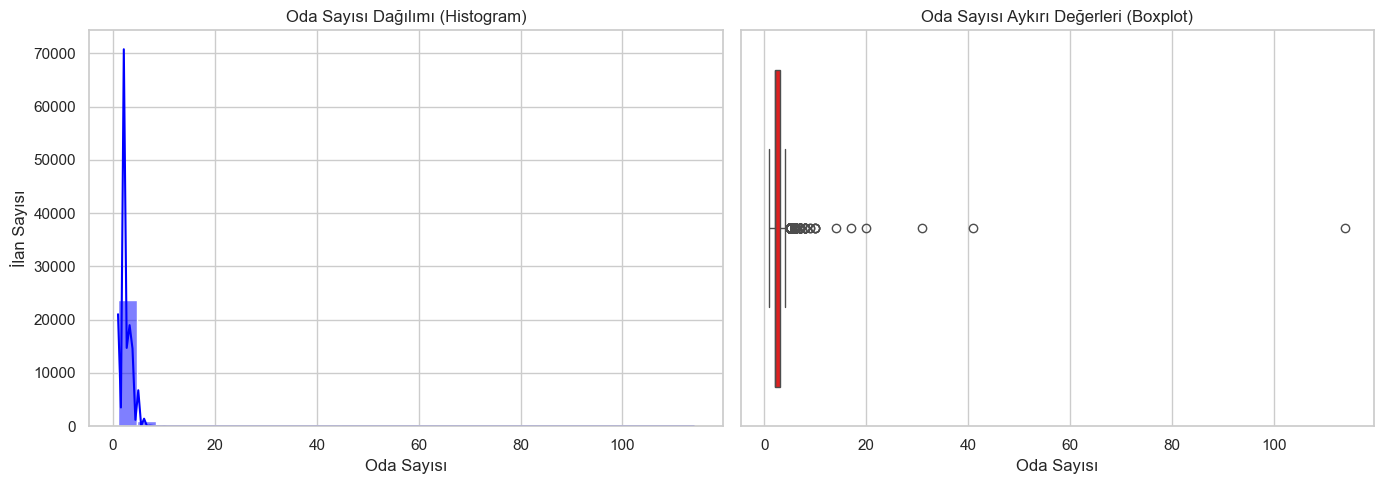

In [13]:
# Grafiklerin boyutunu ve temasını ayarlayalım
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 1. Grafik: Histogram (Dağılım)
plt.subplot(1, 2, 1)
sns.histplot(df['rooms'], bins=30, kde=True, color='blue')
plt.title('Oda Sayısı Dağılımı (Histogram)')
plt.xlabel('Oda Sayısı')
plt.ylabel('İlan Sayısı')

# 2. Grafik: Boxplot (Aykırı Değer Avı)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['rooms'], color='red')
plt.title('Oda Sayısı Aykırı Değerleri (Boxplot)')
plt.xlabel('Oda Sayısı')

plt.tight_layout()
plt.show()

In [14]:
df["rooms"].value_counts()

rooms
2      10941
3       7896
4       2578
1       2337
5        760
6        196
7         36
8         11
10         4
9          2
14         1
31         1
20         1
41         1
17         1
114        1
Name: count, dtype: int64

In [15]:
# 1. Çeyrek (Q1) ve 3. Çeyrek (Q3) değerlerini hesapla
Q1 = df['rooms'].quantile(0.25)
Q3 = df['rooms'].quantile(0.75)

# IQR hesapla
IQR = Q3 - Q1

# Alt ve Üst Sınırları Belirle
alt_sinir = Q1 - 1.5 * IQR
ust_sinir = Q3 + 1.5 * IQR

print(f"Oda Sayısı için Matematiksel Alt Sınır: {alt_sinir}")
print(f"Oda Sayısı için Matematiksel Üst Sınır: {ust_sinir}")


print(f"IQR temizliği sonrası kalan veri sayısı: {len(df)}")

Oda Sayısı için Matematiksel Alt Sınır: 0.5
Oda Sayısı için Matematiksel Üst Sınır: 4.5
IQR temizliği sonrası kalan veri sayısı: 24767


In [16]:
df=df[df['rooms'] <= 10]

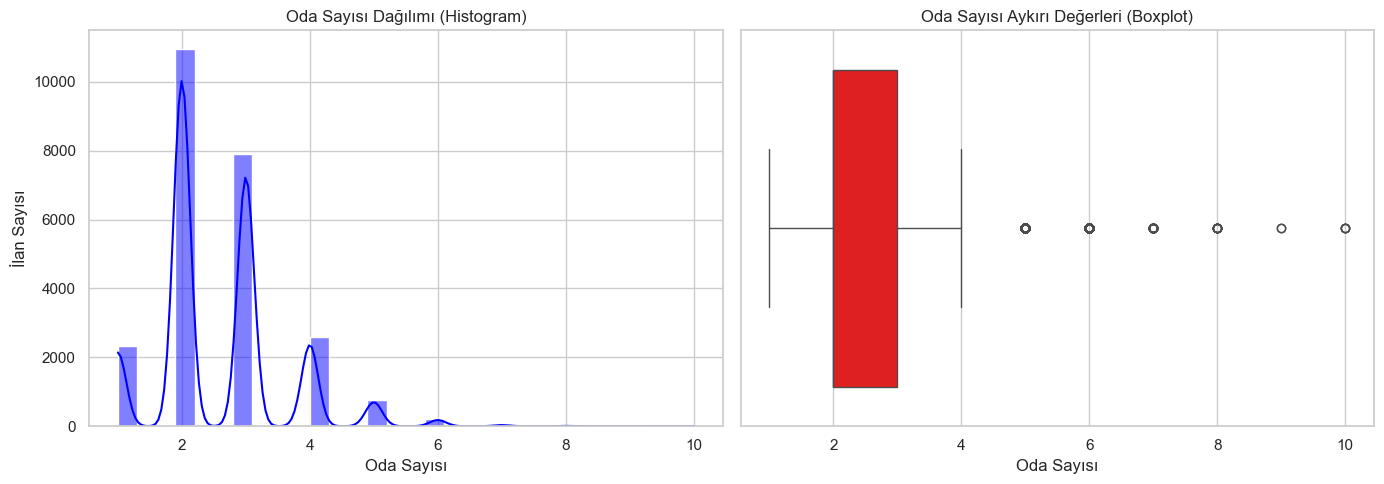

In [17]:
# Grafiklerin boyutunu ve temasını ayarlayalım
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 1. Grafik: Histogram (Dağılım)
plt.subplot(1, 2, 1)
sns.histplot(df['rooms'], bins=30, kde=True, color='blue')
plt.title('Oda Sayısı Dağılımı (Histogram)')
plt.xlabel('Oda Sayısı')
plt.ylabel('İlan Sayısı')

# 2. Grafik: Boxplot (Aykırı Değer Avı)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['rooms'], color='red')
plt.title('Oda Sayısı Aykırı Değerleri (Boxplot)')
plt.xlabel('Oda Sayısı')

plt.tight_layout()
plt.show()

In [18]:
df["rooms"].value_counts()


rooms
2     10941
3      7896
4      2578
1      2337
5       760
6       196
7        36
8        11
10        4
9         2
Name: count, dtype: int64

In [19]:
df['halls'].value_counts()

halls
1     22227
2      2159
0       309
3        29
10       19
4        11
11        4
20        1
12        1
5         1
Name: count, dtype: int64

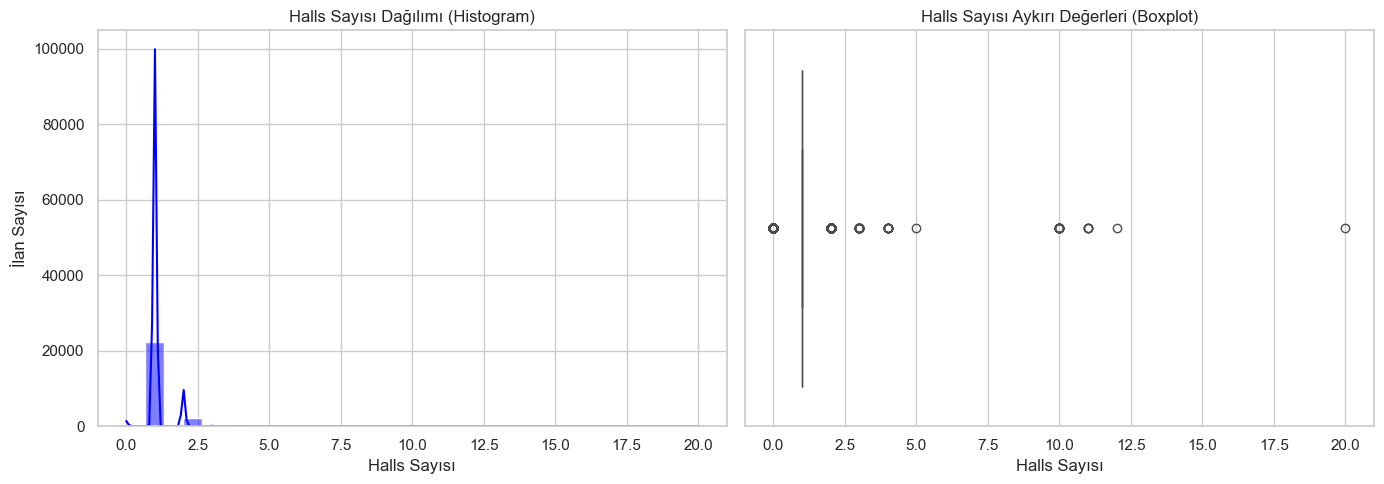

In [20]:
# Grafiklerin boyutunu ve temasını ayarlayalım
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 1. Grafik: Histogram (Dağılım)
plt.subplot(1, 2, 1)
sns.histplot(df['halls'], bins=30, kde=True, color='blue')
plt.title('Halls Sayısı Dağılımı (Histogram)')
plt.xlabel('Halls Sayısı')
plt.ylabel('İlan Sayısı')

# 2. Grafik: Boxplot (Aykırı Değer Avı)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['halls'], color='red')
plt.title('Halls Sayısı Aykırı Değerleri (Boxplot)')
plt.xlabel('Halls Sayısı')

plt.tight_layout()
plt.show()

In [21]:
df = df[df['halls'] <= 4]

In [22]:
df["halls"].value_counts()

halls
1    22227
2     2159
0      309
3       29
4       11
Name: count, dtype: int64

In [23]:
df["gross_sqm"].value_counts()

gross_sqm
90.00     1680
100.00    1413
85.00     1388
120.00    1286
110.00    1265
          ... 
490.00       1
488.00       1
283.00       1
324.00       1
376.00       1
Name: count, Length: 342, dtype: int64

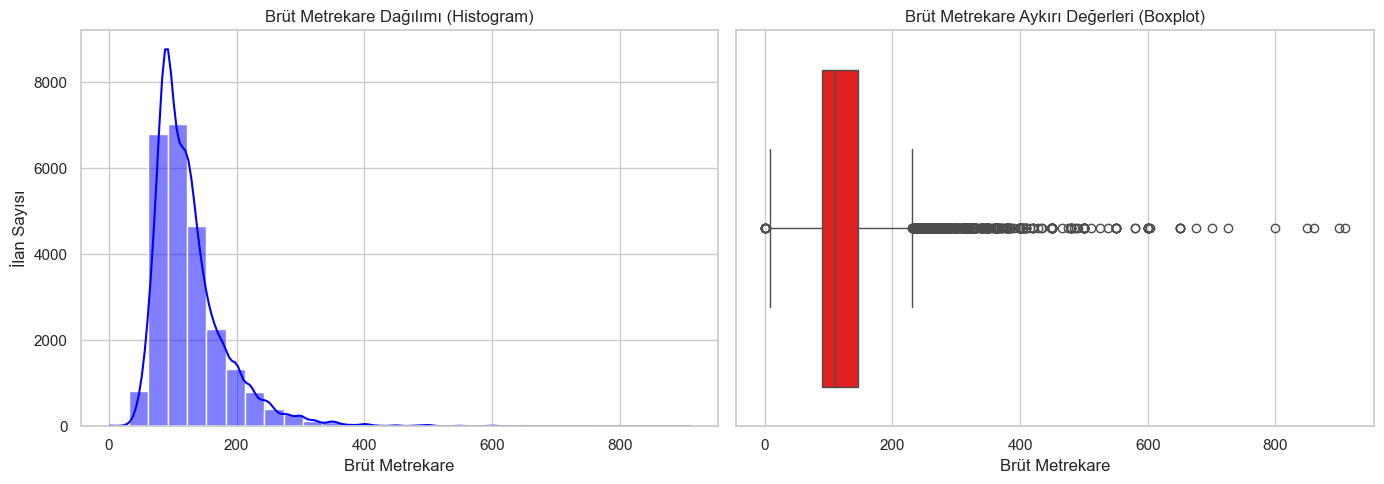

In [24]:
# Grafiklerin boyutunu ve temasını ayarlayalım
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 1. Grafik: Histogram (Dağılım)
plt.subplot(1, 2, 1)
sns.histplot(df['gross_sqm'], bins=30, kde=True, color='blue')
plt.title('Brüt Metrekare Dağılımı (Histogram)')
plt.xlabel('Brüt Metrekare')
plt.ylabel('İlan Sayısı')

# 2. Grafik: Boxplot (Aykırı Değer Avı)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['gross_sqm'], color='red')
plt.title('Brüt Metrekare Aykırı Değerleri (Boxplot)')
plt.xlabel('Brüt Metrekare')

plt.tight_layout()
plt.show()

In [25]:
df = df[(df['gross_sqm'] >= 20) & (df['gross_sqm'] <= 600)]

In [26]:
df["gross_sqm"].value_counts()

gross_sqm
90.00     1680
100.00    1413
85.00     1388
120.00    1286
110.00    1265
          ... 
490.00       1
488.00       1
283.00       1
324.00       1
376.00       1
Name: count, Length: 328, dtype: int64

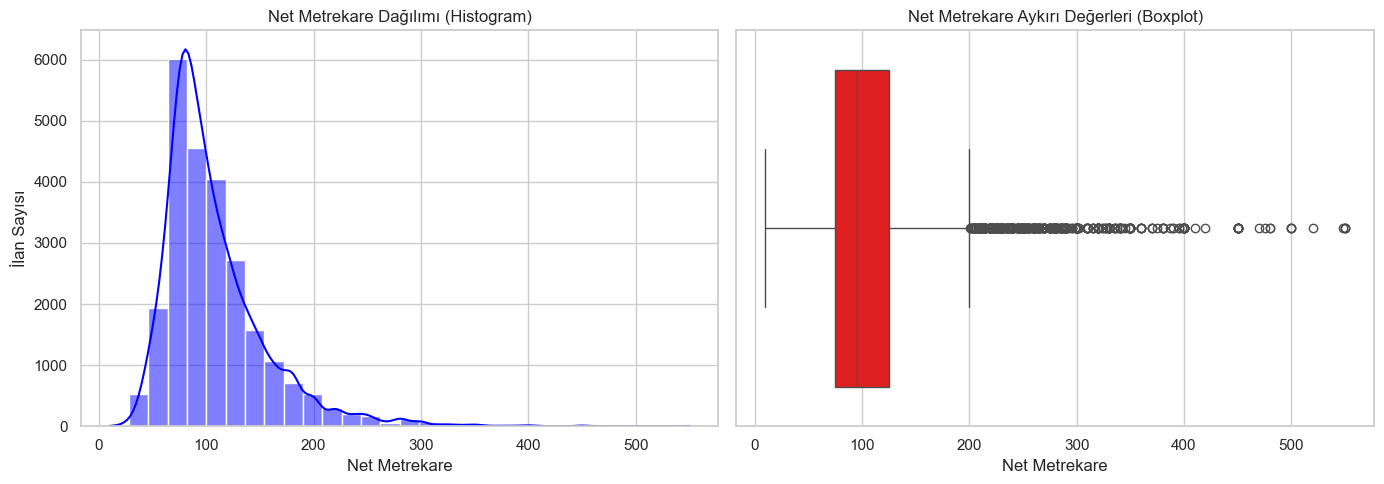

In [27]:
# Grafiklerin boyutunu ve temasını ayarlayalım
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 1. Grafik: Histogram (Dağılım)
plt.subplot(1, 2, 1)
sns.histplot(df['net_sqm'], bins=30, kde=True, color='blue')
plt.title('Net Metrekare Dağılımı (Histogram)')
plt.xlabel('Net Metrekare')
plt.ylabel('İlan Sayısı')

# 2. Grafik: Boxplot (Aykırı Değer Avı)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['net_sqm'], color='red')
plt.title('Net Metrekare Aykırı Değerleri (Boxplot)')
plt.xlabel('Net Metrekare')

plt.tight_layout()
plt.show()

In [28]:
df["net_sqm"].value_counts()

net_sqm
80.00     1697
90.00     1549
100.00    1437
75.00     1312
85.00     1252
          ... 
302.00       1
293.00       1
342.00       1
233.00       1
201.00       1
Name: count, Length: 285, dtype: int64

In [29]:
df = df[df['net_sqm'] >= 15]
df = df[df['net_sqm'] < df['gross_sqm']]

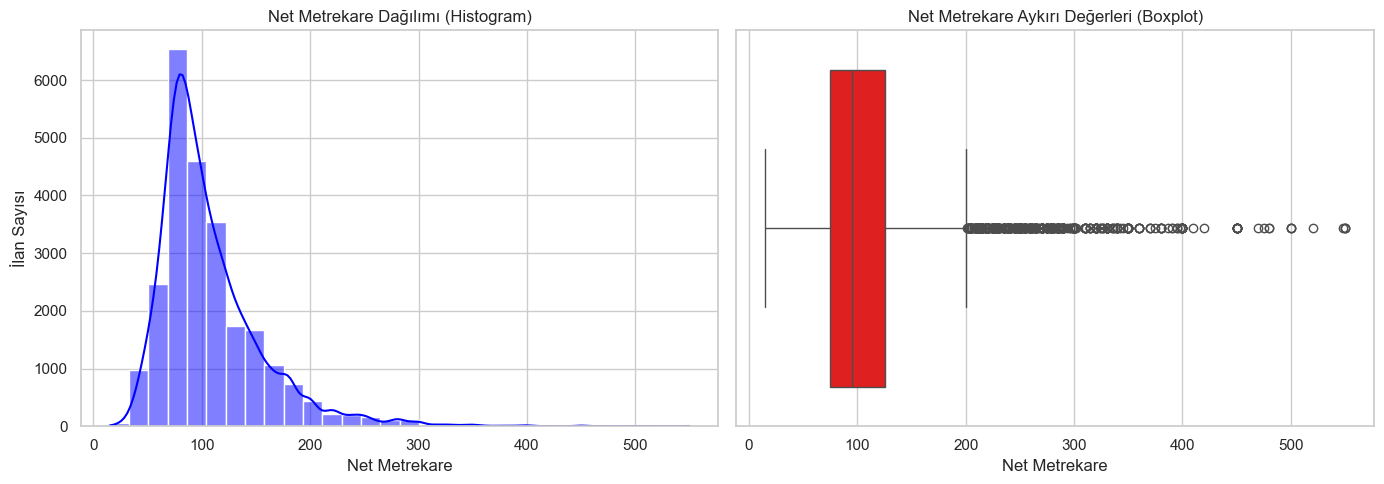

In [30]:
# Grafiklerin boyutunu ve temasını ayarlayalım
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 1. Grafik: Histogram (Dağılım)
plt.subplot(1, 2, 1)
sns.histplot(df['net_sqm'], bins=30, kde=True, color='blue')
plt.title('Net Metrekare Dağılımı (Histogram)')
plt.xlabel('Net Metrekare')
plt.ylabel('İlan Sayısı')

# 2. Grafik: Boxplot (Aykırı Değer Avı)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['net_sqm'], color='red')
plt.title('Net Metrekare Aykırı Değerleri (Boxplot)')
plt.xlabel('Net Metrekare')

plt.tight_layout()
plt.show()

In [31]:
print(df['building_age'].value_counts().sort_index(ascending=False).head(20))

building_age
400    1
203    1
182    1
155    1
140    1
130    1
125    1
120    1
110    2
109    1
106    1
105    2
99     1
94     2
92     1
83     1
80     2
75     2
73     1
70     3
Name: count, dtype: int64


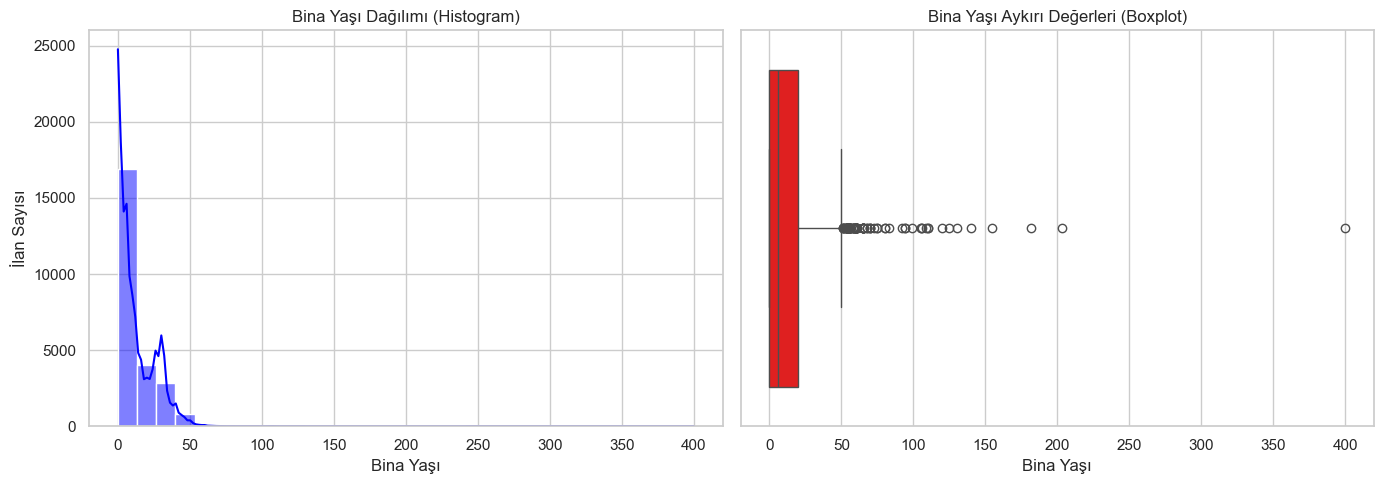

In [32]:
# Grafiklerin boyutunu ve temasını ayarlayalım
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 1. Grafik: Histogram (Dağılım)
plt.subplot(1, 2, 1)
sns.histplot(df['building_age'], bins=30, kde=True, color='blue')
plt.title('Bina Yaşı Dağılımı (Histogram)')
plt.xlabel('Bina Yaşı')
plt.ylabel('İlan Sayısı')

# 2. Grafik: Boxplot (Aykırı Değer Avı)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['building_age'], color='red')
plt.title('Bina Yaşı Aykırı Değerleri (Boxplot)')
plt.xlabel('Bina Yaşı')

plt.tight_layout()
plt.show()

In [33]:
df = df[df['building_age'] <= 70]

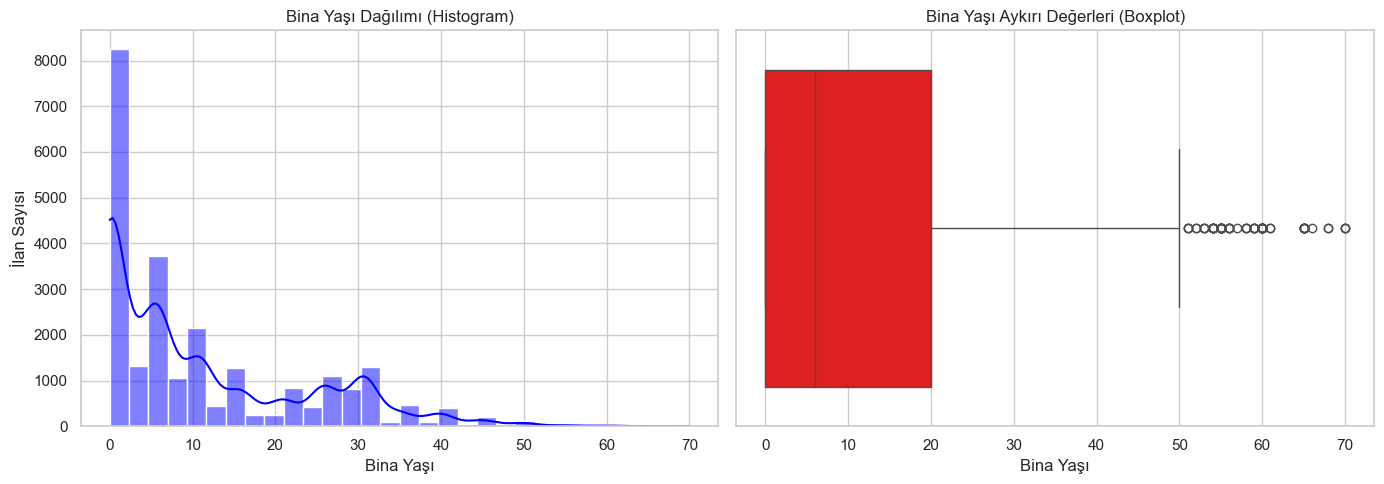

In [34]:
# Grafiklerin boyutunu ve temasını ayarlayalım
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 1. Grafik: Histogram (Dağılım)
plt.subplot(1, 2, 1)
sns.histplot(df['building_age'], bins=30, kde=True, color='blue')
plt.title('Bina Yaşı Dağılımı (Histogram)')
plt.xlabel('Bina Yaşı')
plt.ylabel('İlan Sayısı')

# 2. Grafik: Boxplot (Aykırı Değer Avı)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['building_age'], color='red')
plt.title('Bina Yaşı Aykırı Değerleri (Boxplot)')
plt.xlabel('Bina Yaşı')

plt.tight_layout()
plt.show()

In [35]:
df.describe()

,price,rooms,halls,gross_sqm,net_sqm,floor,total_floors,building_age,bathroom_count,is_in_complex
count,24688.00,24688.00,24688.00,24688.00,24688.00,22785.00,24687.00,24688.00,24456.00,24688.00
mean,13344389.74,2.56,1.08,126.00,107.18,2.80,6.63,11.21,1.50,0.22
std,141644469.10,0.98,0.32,56.27,48.11,3.23,6.73,12.46,0.73,0.42
min,24000.00,1.00,0.00,24.00,15.00,-3.00,1.00,0.00,1.00,0.00
25%,4500000.00,2.00,1.00,90.00,75.00,1.00,4.00,0.00,1.00,0.00
50%,6750000.00,2.00,1.00,110.00,95.00,2.00,5.00,6.00,1.00,0.00
75%,11500000.00,3.00,1.00,145.00,125.00,4.00,7.00,20.00,2.00,0.00
max,11500000000.00,9.00,4.00,600.00,550.00,20.00,450.00,70.00,21.00,1.00


In [36]:
df.head()

,price,district,neighborhood,rooms,halls,gross_sqm,net_sqm,floor,total_floors,building_age,heating_type,bathroom_count,furnished,usage_status,is_in_complex,orientation,credit_eligible,deed_status,exchange
0,15900000,Adalar,Maden,3,1,138.00,96.00,3.00,3.00,55,Air Conditioning,2.00,Furnished,Vacant,0,"North, South, East, West",Not Eligible,Land Title,No
1,40000000,Adalar,Nizam,4,1,199.00,150.00,-1.00,3.00,0,Combi Boiler,4.00,Unfurnished,Vacant,1,"North, South, East, West",Eligible,Construction Easement,No
2,17850000,Adalar,Nizam,2,1,107.00,81.00,1.00,5.00,54,Combi Boiler,3.00,Furnished,Vacant,0,"North, East, West",Eligible,Condominium Title,No
3,16000000,Adalar,Heybeliada,3,1,200.00,196.00,NaN,3.00,35,Combi Boiler,2.00,Unfurnished,Owner-occupied,0,"North, West",Eligible,Condominium Title,No
4,14000000,Adalar,Nizam,4,1,160.00,145.00,-1.00,3.00,40,Floor Radiator,1.00,Unfurnished,Vacant,0,NaN,Eligible,Condominium Title,No


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24688 entries, 0 to 24766
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   price            24688 non-null  int64  
 1   district         24688 non-null  object 
 2   neighborhood     24688 non-null  object 
 3   rooms            24688 non-null  int64  
 4   halls            24688 non-null  int64  
 5   gross_sqm        24688 non-null  float64
 6   net_sqm          24688 non-null  float64
 7   floor            22785 non-null  float64
 8   total_floors     24687 non-null  float64
 9   building_age     24688 non-null  int64  
 10  heating_type     24688 non-null  object 
 11  bathroom_count   24456 non-null  float64
 12  furnished        23619 non-null  object 
 13  usage_status     24064 non-null  object 
 14  is_in_complex    24688 non-null  int64  
 15  orientation      19396 non-null  object 
 16  credit_eligible  24681 non-null  object 
 17  deed_status      

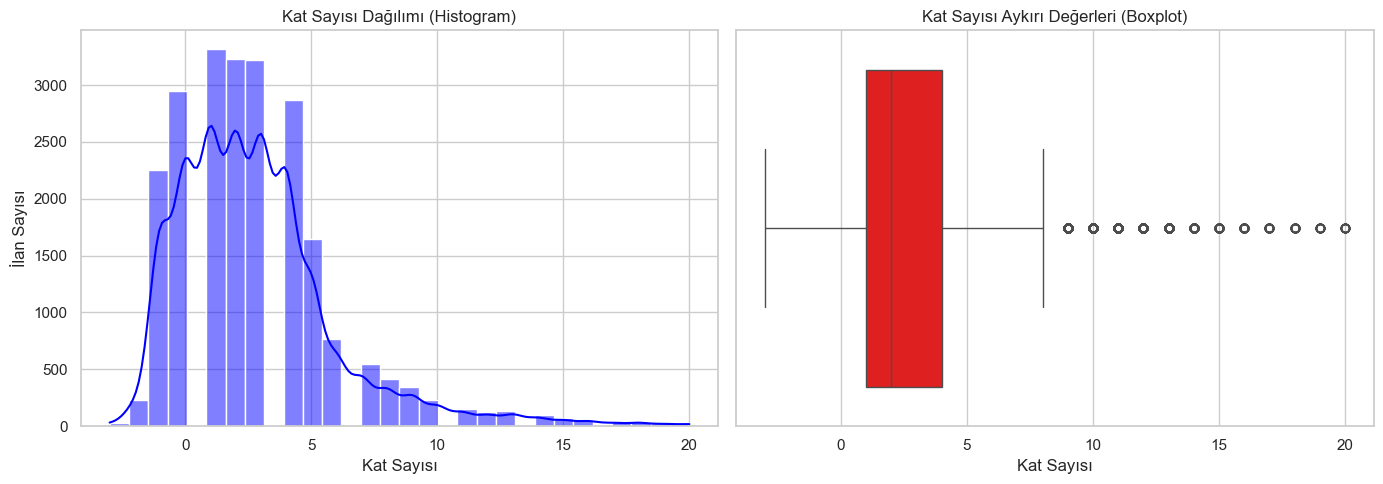

In [38]:
# Grafiklerin boyutunu ve temasını ayarlayalım
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 1. Grafik: Histogram (Dağılım)
plt.subplot(1, 2, 1)
sns.histplot(df['floor'], bins=30, kde=True, color='blue')
plt.title('Kat Sayısı Dağılımı (Histogram)')
plt.xlabel('Kat Sayısı')
plt.ylabel('İlan Sayısı')

# 2. Grafik: Boxplot (Aykırı Değer Avı)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['floor'], color='red')
plt.title('Kat Sayısı Aykırı Değerleri (Boxplot)')
plt.xlabel('Kat Sayısı')

plt.tight_layout()
plt.show()

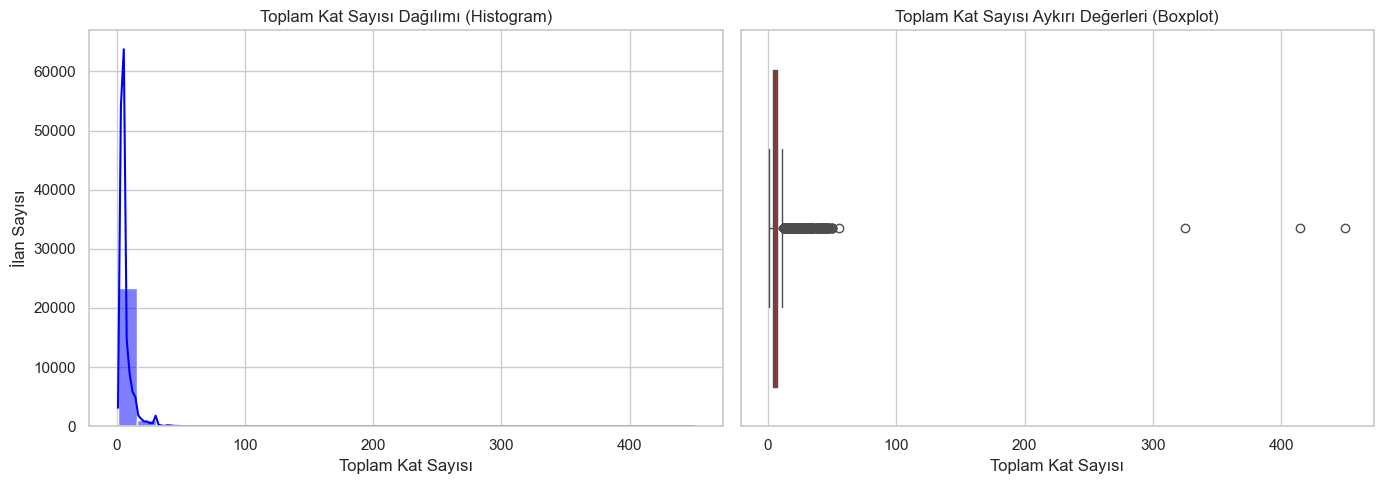

In [39]:
# Grafiklerin boyutunu ve temasını ayarlayalım
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 1. Grafik: Histogram (Dağılım)
plt.subplot(1, 2, 1)
sns.histplot(df['total_floors'], bins=30, kde=True, color='blue')
plt.title('Toplam Kat Sayısı Dağılımı (Histogram)')
plt.xlabel('Toplam Kat Sayısı')
plt.ylabel('İlan Sayısı')

# 2. Grafik: Boxplot (Aykırı Değer Avı)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['total_floors'], color='red')
plt.title('Toplam Kat Sayısı Aykırı Değerleri (Boxplot)')
plt.xlabel('Toplam Kat Sayısı')

plt.tight_layout()
plt.show()

In [40]:
df = df[df['total_floors'] <= 70]
df = df[df['floor'] <= 50]
df = df[df['floor'] <= df['total_floors']]

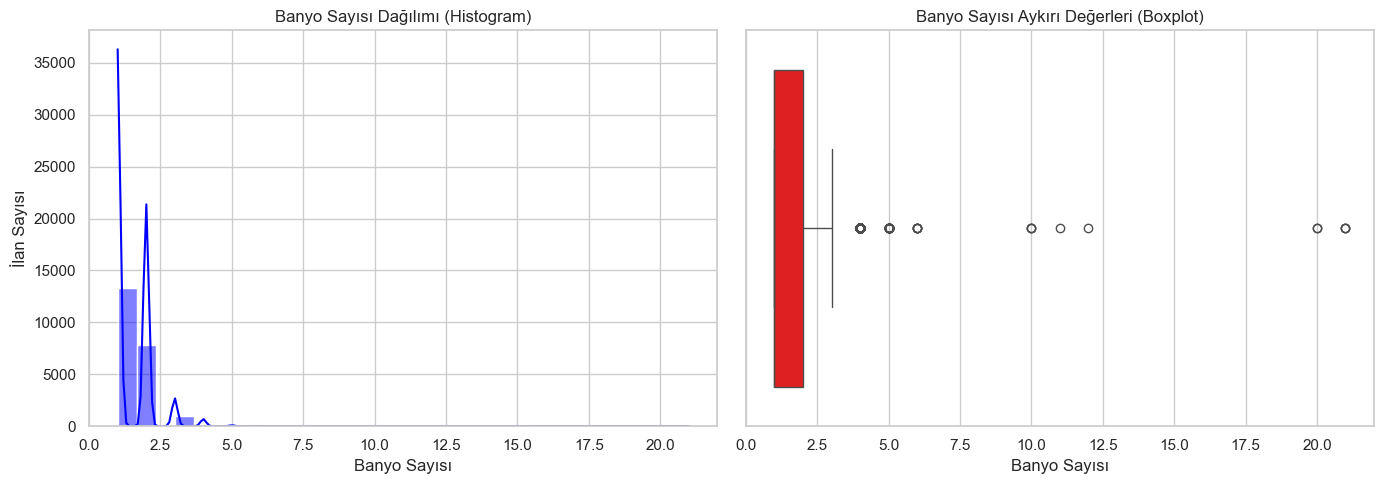

In [41]:
# Grafiklerin boyutunu ve temasını ayarlayalım
plt.figure(figsize=(14, 5))
sns.set_theme(style="whitegrid")

# 1. Grafik: Histogram (Dağılım)
plt.subplot(1, 2, 1)
sns.histplot(df['bathroom_count'], bins=30, kde=True, color='blue')
plt.title('Banyo Sayısı Dağılımı (Histogram)')
plt.xlabel('Banyo Sayısı')
plt.ylabel('İlan Sayısı')

# 2. Grafik: Boxplot (Aykırı Değer Avı)
plt.subplot(1, 2, 2)
sns.boxplot(x=df['bathroom_count'], color='red')
plt.title('Banyo Sayısı Aykırı Değerleri (Boxplot)')
plt.xlabel('Banyo Sayısı')

plt.tight_layout()
plt.show()

In [42]:
df = df[df['bathroom_count'] <= 5]

In [43]:
df["is_in_complex"].value_counts()

is_in_complex
0    17439
1     5066
Name: count, dtype: int64

In [44]:
print(f"Güncel Satır Sayısı: {len(df)}")
print("\nBoş Değerlerin Dağılımı:")
print(df.isnull().sum())

Güncel Satır Sayısı: 22505

Boş Değerlerin Dağılımı:
price                 0
district              0
neighborhood          0
rooms                 0
halls                 0
gross_sqm             0
net_sqm               0
floor                 0
total_floors          0
building_age          0
heating_type          0
bathroom_count        0
furnished           900
usage_status        501
is_in_complex         0
orientation        4861
credit_eligible       7
deed_status           1
exchange           1341
dtype: int64


In [45]:
# 1. Çok az eksiği olan satırları direkt uçuralım
df.dropna(subset=['credit_eligible', 'deed_status'], inplace=True)

# 2. Fazla eksiği olan kategorik sütunları "Bilinmiyor" ile dolduralım
cols_to_fill = ['orientation', 'exchange', 'furnished', 'usage_status']

for col in cols_to_fill:
    df[col] = df[col].fillna("Bilinmiyor")

# 3. Sonuç Kontrolü: 0 görmemiz lazım
print("Kalan Toplam Boş Hücre Sayısı:", df.isnull().sum().sum())
print("Final Satır Sayısı:", len(df))

Kalan Toplam Boş Hücre Sayısı: 0
Final Satır Sayısı: 22497


In [46]:
df=df[(df['price'] >= 1000000) & (df['price'] <= 150000000)].copy()

In [47]:
from sklearn.model_selection import train_test_split
X = df.drop('price', axis=1)
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Eğitim seti boyutu: {len(X_train)}")
print(f"Test seti boyutu: {len(X_test)}")

Eğitim seti boyutu: 17956
Test seti boyutu: 4489


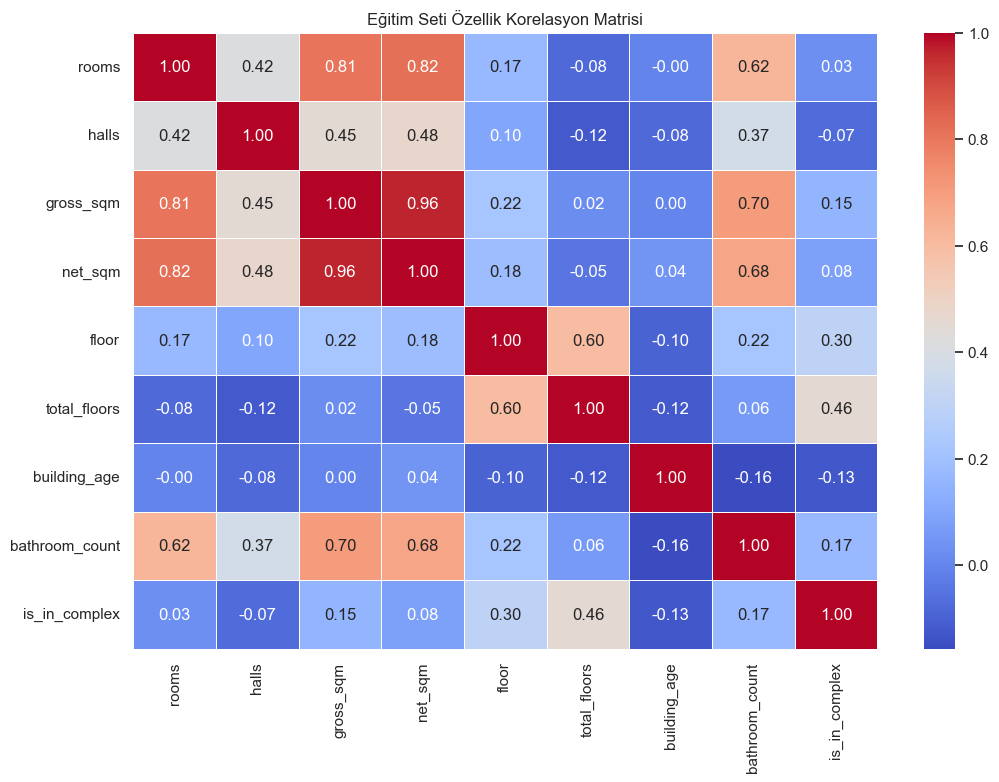

In [48]:
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = X_train[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Eğitim Seti Özellik Korelasyon Matrisi")
plt.show()

In [49]:
X_train.drop('gross_sqm', axis=1, inplace=True)
X_test.drop('gross_sqm', axis=1, inplace=True)

In [50]:
#target encoding
# Sadece Train setinden ortalamaları öğreniyoruz 
neighborhood_means = y_train.groupby(X_train['neighborhood']).mean()

# Öğrendiğimiz bu değerleri her iki sete de yansıtıyoruz
X_train['neighborhood_target'] = X_train['neighborhood'].map(neighborhood_means)
X_test['neighborhood_target'] = X_test['neighborhood'].map(neighborhood_means)

# Test setinde yeni bir mahalle çıkarsa (Train'de olmayan), genel ortalamayı basıyoruz
X_test['neighborhood_target'] = X_test['neighborhood_target'].fillna(y_train.mean())

In [51]:
X_train.drop('neighborhood', axis=1, inplace=True)
X_test.drop('neighborhood', axis=1, inplace=True)

In [52]:
X_train.head()

,district,rooms,halls,net_sqm,floor,total_floors,building_age,heating_type,bathroom_count,furnished,usage_status,is_in_complex,orientation,credit_eligible,deed_status,exchange,neighborhood_target
19331,Sarıyer,2,1,65.00,0.00,3.00,31,Air Conditioning,1.00,Bilinmiyor,Vacant,0,East,Eligible,Condominium Title,No,31311111.11
8568,Çekmeköy,2,1,55.00,1.00,6.00,0,Combi Boiler,1.00,Unfurnished,Vacant,0,East,Eligible,Condominium Title,No,6215695.65
3469,Bahçelievler,1,1,60.00,0.00,4.00,0,Combi Boiler,1.00,Unfurnished,Bilinmiyor,0,South,Eligible,Construction Easement,No,6251618.50
6512,Beylikdüzü,3,1,150.00,1.00,8.00,10,Combi Boiler,2.00,Unfurnished,Vacant,0,"South, East",Eligible,Condominium Title,Yes,7011257.53
24446,Zeytinburnu,2,1,65.00,2.00,9.00,0,Combi Boiler,1.00,Unfurnished,Vacant,1,South,Eligible,Condominium Title,No,6722941.18


In [53]:
#one-hot encoding
cols_to_encode = ['district', 'heating_type', 'furnished', 'usage_status', 
                  'orientation', 'credit_eligible', 'deed_status', 'exchange']
X_train = pd.get_dummies(X_train, columns=cols_to_encode, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cols_to_encode, drop_first=True)                  

In [54]:
X_train.head()

,rooms,halls,net_sqm,floor,total_floors,building_age,bathroom_count,is_in_complex,neighborhood_target,district_Arnavutköy,...,deed_status_Cooperative Share,deed_status_Foreign Owner,deed_status_Foundation/Association,deed_status_Freehold Title,deed_status_Land Title,deed_status_No Title Deed,deed_status_Shared Title,deed_status_Usufruct Right,exchange_No,exchange_Yes
19331,2,1,65.00,0.00,3.00,31,1.00,0,31311111.11,False,...,False,False,False,False,False,False,False,False,True,False
8568,2,1,55.00,1.00,6.00,0,1.00,0,6215695.65,False,...,False,False,False,False,False,False,False,False,True,False
3469,1,1,60.00,0.00,4.00,0,1.00,0,6251618.50,False,...,False,False,False,False,False,False,False,False,True,False
6512,3,1,150.00,1.00,8.00,10,2.00,0,7011257.53,False,...,False,False,False,False,False,False,False,False,False,True
24446,2,1,65.00,2.00,9.00,0,1.00,1,6722941.18,False,...,False,False,False,False,False,False,False,False,True,False


In [55]:
X_train.isnull().sum().sum()

np.int64(0)

In [56]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor,AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Lasso Regression": Lasso(),
    "ElasticNet": ElasticNet(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostRegressor(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "SVR": SVR(kernel='rbf'),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print("Model:", name)
    print(f"{name} - MSE: {mse:.2f}, R²: {r2:.4f}, MAE: {mae:.2f}")
    print("-" * 50)

Model: Linear Regression
Linear Regression - MSE: 44359865911424.47, R²: 0.6960, MAE: 3636269.45
--------------------------------------------------
Model: Ridge Regression
Ridge Regression - MSE: 44359722275527.77, R²: 0.6960, MAE: 3636113.87
--------------------------------------------------
Model: Lasso Regression
Lasso Regression - MSE: 44359875449683.20, R²: 0.6960, MAE: 3636267.17
--------------------------------------------------
Model: ElasticNet
ElasticNet - MSE: 50536184559047.43, R²: 0.6536, MAE: 3473760.23
--------------------------------------------------
Model: Random Forest
Random Forest - MSE: 26340098895972.68, R²: 0.8195, MAE: 2160873.07
--------------------------------------------------
Model: Gradient Boosting
Gradient Boosting - MSE: 33522596015034.03, R²: 0.7702, MAE: 2691752.09
--------------------------------------------------
Model: AdaBoost
AdaBoost - MSE: 108474002545733.92, R²: 0.2565, MAE: 8104480.50
--------------------------------------------------
Model: 

c:\Users\aalim\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [59]:
from sklearn.model_selection import RandomizedSearchCV
xgboost_params = {
        "learning_rate" : [0.1, 0.01],
        "max_depth" : [4, 5, 6,8,10],
        "n_estimators" : [100,200,300,500],
        "colsample_bytree" :[0.3, 0.4, 0.5, 0.7, 1],
        "subsample" : [0.5, 0.7, 1]
}

In [60]:
randomized_search = RandomizedSearchCV(estimator=XGBRegressor(), param_distributions=xgboost_params, cv = 5, n_jobs = -1, n_iter = 20,verbose=1, random_state=42)
randomized_search.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.3, 0.4, ...], 'learning_rate': [0.1, 0.01], 'max_depth': [4, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... 

In [61]:
randomized_search.best_params_

{'subsample': 1,
 'n_estimators': 500,
 'max_depth': 10,
 'learning_rate': 0.1,
 'colsample_bytree': 0.7}

In [79]:
model = XGBRegressor(subsample=0.8,n_estimators=300, max_depth=6, learning_rate=0.05, colsample_bytree=0.8)

In [80]:
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
model_mse = mean_squared_error(y_test, y_pred)
model_r2 = r2_score(y_test, y_pred)
model_mae = mean_absolute_error(y_test, y_pred)

In [81]:
print("mse: ", model_mse)
print("r2: ", model_r2)
print("mae: ", model_mae)

mse:  25035636998144.0
r2:  0.8284048438072205
mae:  2242854.25


In [83]:
# 1. Eğitim seti tahminlerini alalım
y_train_pred = model.predict(X_train_scaled)

# 2. Skorları kıyaslayalım
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = model_r2 # Zaten hesaplamıştık 

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = model_mae # Zaten hesaplamıştık 

print(f"--- Overfitting Kontrolü ---")
print(f"Eğitim (Train) R2: %{train_r2*100:.2f}")
print(f"Test R2:           %{test_r2*100:.2f}")
print("-" * 30)
print(f"Eğitim (Train) MAE: {train_mae:.2f} TL")
print(f"Test MAE:           {test_mae:.2f} TL")



--- Overfitting Kontrolü ---
Eğitim (Train) R2: %94.55
Test R2:           %82.84
------------------------------
Eğitim (Train) MAE: 1661469.62 TL
Test MAE:           2242854.25 TL


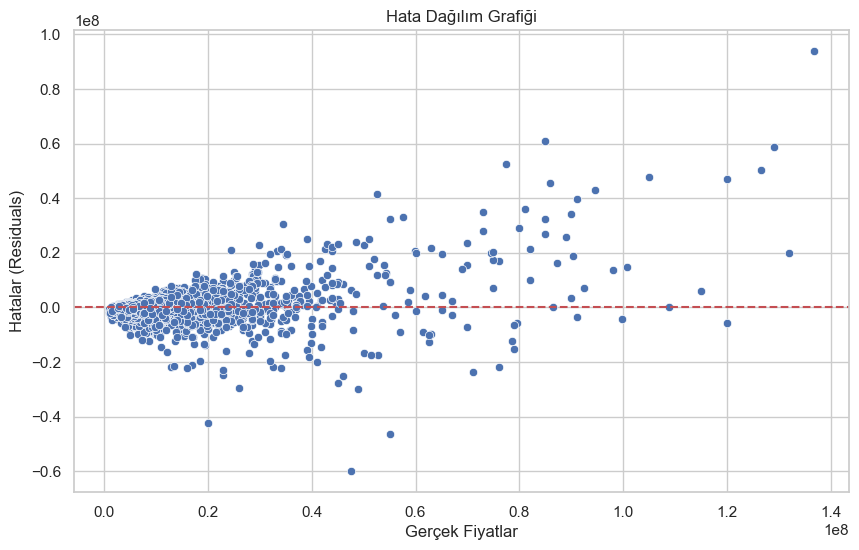

In [85]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Gerçek Fiyatlar')
plt.ylabel('Hatalar (Residuals)')
plt.title('Hata Dağılım Grafiği')
plt.show()

In [86]:
import pickle


model_package = {
    "model": model,
    "scaler": scaler,
    "neighborhood_means": neighborhood_means,
    "training_columns": X_train.columns.tolist()
}


with open("house_price_model.pkl", "wb") as f:
    pickle.dump(model_package, f)